# Reproducible RTHYM-MOC Runs

This notebook now serves two complementary purposes:

1. A dedicated validation section compares RTHYM-MOC against the checked-in R-THYM benchmark trace and peak metrics used by the automated regression suite.
2. A separate exploratory section uses a shortened valve-closure schedule to make the transient behavior easier to inspect graphically.
3. Repeated runs and seeded synthetic inputs demonstrate that the workflow is reproducible when the inputs are held fixed.

The notebook uses checked-in benchmark assets from this repository so both the validation workflow and the exploratory plots stay tied to deterministic, version-controlled inputs.

## 1. Install and Import Dependencies

This repo already contains the package source, benchmark assets, and examples. The next cell resolves the repository root, imports the Python libraries used in the notebook, and reports the package version that produced the results.

In [14]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np

import rthym_moc
from rthym_moc import load_inp

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "tests").exists():
    REPO_ROOT = Path("/home/jason/RTHYM-MOC")

EXAMPLES_DIR = REPO_ROOT / "examples"
TESTS_DIR = REPO_ROOT / "tests"
OUTPUT_DIR = EXAMPLES_DIR / "notebook_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

ASSET_INP = TESTS_DIR / "Joukowsky Benchmark.inp"
ASSET_JSON = TESTS_DIR / "R-THYM_Joukowsky_Verification.json"
ASSET_CSV = TESTS_DIR / "R-THYM_Joukowsky_Traces.csv"

print(f"Repository root: {REPO_ROOT}")
print(f"Using INP asset : {ASSET_INP.name}")
print(f"Using JSON asset: {ASSET_JSON.name}")
print(f"Using CSV asset : {ASSET_CSV.name}")
print(f"rthym_moc version: {getattr(rthym_moc, '__version__', 'unknown')}")

Repository root: /home/jason/RTHYM-MOC
Using INP asset : Joukowsky Benchmark.inp
Using JSON asset: R-THYM_Joukowsky_Verification.json
Using CSV asset : R-THYM_Joukowsky_Traces.csv
rthym_moc version: 0.1.0


## 2. Load a Deterministic Network Model

The benchmark suite already ships a fixed EPANET input file, a checked-in JSON export from the R-THYM reference run, and a reference pressure trace CSV. The next cell prepares both the original benchmark schedule for formal validation and a shortened 2-second closure schedule for exploratory charting.

In [15]:
reference = json.loads(ASSET_JSON.read_text())
reference_trace = np.loadtxt(ASSET_CSV, delimiter=",", skiprows=1, usecols=(0, 1, 2))
reference_trace_time = reference_trace[:, 0]
reference_trace_pressure = reference_trace[:, 1]
reference_trace_flow = reference_trace[:, 2]
steady_nodes = reference["steadyState"]["nodes"]
steady_pipes = reference["steadyState"]["pipes"]
reference_valve_schedule = [
    (float(point["t"]), float(point["pct"]))
    for point in reference["valveSchedules"]["Valve_A"]
]
ORIGINAL_CLOSURE_TIME = float(reference_valve_schedule[-1][0])
TARGET_CLOSURE_TIME = 2.0
closure_time_scale = TARGET_CLOSURE_TIME / ORIGINAL_CLOSURE_TIME
exploratory_valve_schedule = [
    (time_s * closure_time_scale, pct_open)
    for time_s, pct_open in reference_valve_schedule
]
REFERENCE_WAVE_SPEED_FTPS = float(reference["waveSpeeds"]["Pipe_1"])
VALIDATION_TRACE_END = ORIGINAL_CLOSURE_TIME + 2.0 * 3000.0 / REFERENCE_WAVE_SPEED_FTPS
VALIDATION_RMS_TOL_PSI = 4.0
VALIDATION_PEAK_TOL_PSI = 15.0

BASE_INITIAL_FLOWS = {
    "Pipe_1": float(steady_pipes["Pipe_1"]["Q_gpm"]),
    "Pipe_2": float(steady_pipes.get("Pipe_2", steady_pipes["Pipe_1"])["Q_gpm"]),
    "Valve_A": float(steady_pipes["Pipe_1"]["Q_gpm"]),
}
BASE_INITIAL_HEADS = {
    "PressureBoundary_A": float(steady_nodes["PressureBoundary_A"]["head"]),
    "PressureBoundary_B": float(steady_nodes["PressureBoundary_B"]["head"]),
    "_VALVE_Valve_A": float(steady_nodes["Valve_A"]["head"]),
}

SIM_TOTAL_TIME = 8.0
SIM_DT = 0.01


def make_solver(applied_valve_schedule) -> rthym_moc.MOCSolver:
    solver = load_inp(
        str(ASSET_INP),
        use_wntr=False,
        initial_flows=BASE_INITIAL_FLOWS,
        initial_heads=BASE_INITIAL_HEADS,
    )
    solver.set_valve_schedule("_VALVE_Valve_A", applied_valve_schedule)
    return solver


validation_solver = make_solver(reference_valve_schedule)
validation_results = validation_solver.run(total_time=SIM_TOTAL_TIME, dt=SIM_DT)
baseline_solver = make_solver(exploratory_valve_schedule)
baseline_results = baseline_solver.run(total_time=SIM_TOTAL_TIME, dt=SIM_DT)
validation_node_ids = sorted(validation_results["node_head"].keys())
node_ids = sorted(baseline_results["node_head"].keys())
pipe_ids = sorted(baseline_results["pipe_flow_gpm"].keys())

print("Validation node IDs:", validation_node_ids)
print("Exploratory node IDs:", node_ids)
print("Pipe IDs:", pipe_ids)
print("Validation schedule points:", len(reference_valve_schedule))
print(f"Validation closure time: {ORIGINAL_CLOSURE_TIME:.2f} s")
print(f"Exploratory closure time: {exploratory_valve_schedule[-1][0]:.2f} s")
print("Time steps in validation run:", len(validation_results["time"]))
print("Time steps in exploratory run:", len(baseline_results["time"]))

Validation node IDs: ['PressureBoundary_A', 'PressureBoundary_B', 'Valve_A_in', 'Valve_A_out', '_VALVE_Valve_A']
Exploratory node IDs: ['PressureBoundary_A', 'PressureBoundary_B', 'Valve_A_in', 'Valve_A_out', '_VALVE_Valve_A']
Pipe IDs: ['Pipe_1', 'Pipe_2', '_P_Valve_A_dn', '_P_Valve_A_up']
Validation schedule points: 2
Validation closure time: 5.96 s
Exploratory closure time: 2.00 s
Time steps in validation run: 800
Time steps in exploratory run: 800


## 3. Validate Against the Checked-In R-THYM Benchmark

The next cells use the original benchmark schedule from the checked-in reference assets. This is the formal validation path: it compares the simulated valve pressure trace and peak pressure against the committed R-THYM reference data using the same early post-closure RMS window that the regression test suite uses.

In [16]:
validation_time = np.asarray(validation_results["time"])
validation_pressure = np.asarray(validation_results["node_pressure"]["_VALVE_Valve_A"])
validation_head = np.asarray(validation_results["node_head"]["_VALVE_Valve_A"])
validation_flow = np.asarray(validation_results["pipe_flow_gpm"]["Pipe_1"])
validation_mask = (reference_trace_time >= ORIGINAL_CLOSURE_TIME) & (reference_trace_time <= VALIDATION_TRACE_END)
validation_ref_time = reference_trace_time[validation_mask]
validation_ref_pressure = reference_trace_pressure[validation_mask]
validation_sim_pressure = np.interp(validation_ref_time + SIM_DT, validation_time, validation_pressure)
validation_pressure_error = validation_sim_pressure - validation_ref_pressure
validation_rms_psi = float(np.sqrt(np.mean(validation_pressure_error ** 2)))
validation_max_abs_error_psi = float(np.max(np.abs(validation_pressure_error)))
validation_peak_mask = validation_time >= ORIGINAL_CLOSURE_TIME
validation_global_peak_pressure = float(np.max(validation_pressure[validation_peak_mask]))
reference_global_peak_pressure = float(reference["peaks"]["Valve_A"]["max"])
validation_global_peak_error_psi = validation_global_peak_pressure - reference_global_peak_pressure
validation_summary = {
    "rms_pressure_error_psi": validation_rms_psi,
    "max_abs_pressure_error_psi": validation_max_abs_error_psi,
    "simulated_global_peak_pressure_psi": validation_global_peak_pressure,
    "reference_global_peak_pressure_psi": reference_global_peak_pressure,
    "global_peak_error_psi": validation_global_peak_error_psi,
    "rms_within_tolerance": validation_rms_psi <= VALIDATION_RMS_TOL_PSI,
    "peak_within_tolerance": abs(validation_global_peak_error_psi) <= VALIDATION_PEAK_TOL_PSI,
}
print(json.dumps(validation_summary, indent=2))

{
  "rms_pressure_error_psi": 2.2748975716188036,
  "max_abs_pressure_error_psi": 12.08863807022135,
  "simulated_global_peak_pressure_psi": 181.33285672247607,
  "reference_global_peak_pressure_psi": 185.5660178854625,
  "global_peak_error_psi": -4.23316116298642,
  "rms_within_tolerance": true,
  "peak_within_tolerance": true
}


### 3a. Overlay the Validation Trace and Error Window

The top panel compares the simulated valve pressure against the checked-in R-THYM trace over the same early post-closure window used by the regression test. The bottom panel shows the pressure difference over time and reports the RMS error directly on the figure.

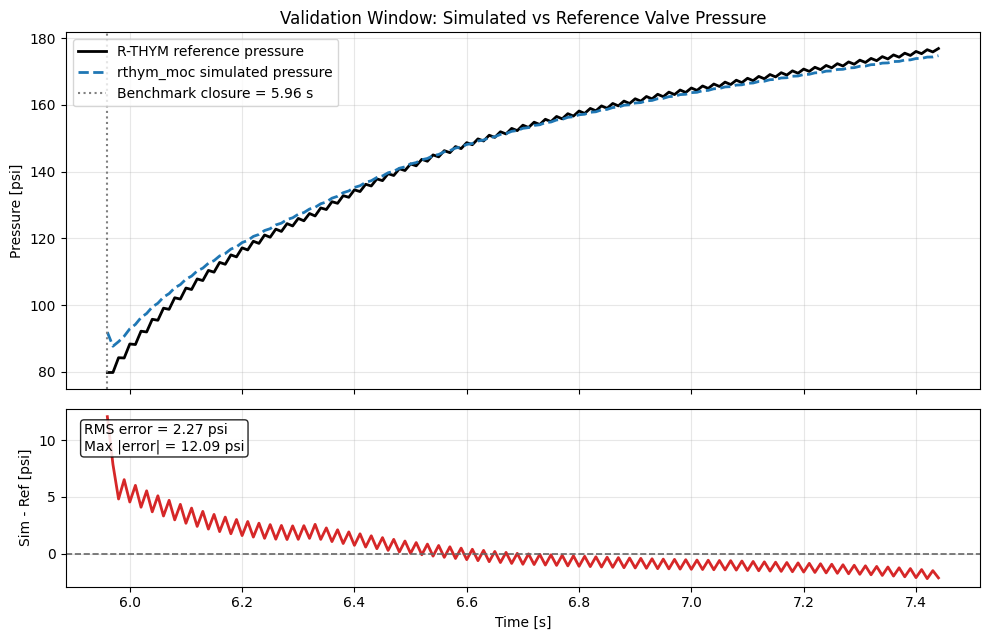

In [17]:
fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True, height_ratios=(3, 1.5))
ax_top.plot(validation_ref_time, validation_ref_pressure, color="black", linewidth=2.0, label="R-THYM reference pressure")
ax_top.plot(validation_ref_time, validation_sim_pressure, color="tab:blue", linewidth=2.0, linestyle="--", label="rthym_moc simulated pressure")
ax_top.axvline(ORIGINAL_CLOSURE_TIME, color="0.5", linestyle=":", linewidth=1.5, label=f"Benchmark closure = {ORIGINAL_CLOSURE_TIME:.2f} s")
ax_top.set_title("Validation Window: Simulated vs Reference Valve Pressure")
ax_top.set_ylabel("Pressure [psi]")
ax_top.grid(True, alpha=0.3)
ax_top.legend(loc="upper left")
ax_bottom.plot(validation_ref_time, validation_pressure_error, color="tab:red", linewidth=2.0)
ax_bottom.axhline(0.0, color="0.4", linestyle="--", linewidth=1.2)
ax_bottom.text(
    0.02, 0.92,
    f"RMS error = {validation_rms_psi:.2f} psi\nMax |error| = {validation_max_abs_error_psi:.2f} psi"
    ,transform=ax_bottom.transAxes,
    va="top",
    bbox={"boxstyle": "round,pad=0.25", "fc": "white", "alpha": 0.85},
)
ax_bottom.set_xlabel("Time [s]")
ax_bottom.set_ylabel("Sim - Ref [psi]")
ax_bottom.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The RMS threshold of 4 psi and the peak-pressure threshold of 15 psi are not notebook-specific choices; they mirror the expectations used by the checked-in Joukowsky benchmark test, so this figure is aligned with the repository's automated validation criteria.

## 4. Explore an Earlier 2-Second Closure Scenario

The remaining charts use a shortened 2-second closure so the transient behavior appears earlier and occupies more of each figure. This is useful for visual exploration, but it is intentionally separate from the formal validation section above.

In [18]:
baseline_time = np.asarray(baseline_results["time"])
baseline_head = np.asarray(baseline_results["node_head"]["_VALVE_Valve_A"])
baseline_pressure = np.asarray(baseline_results["node_pressure"]["_VALVE_Valve_A"])
baseline_upstream_pressure = np.asarray(baseline_results["node_pressure"]["Valve_A_in"])
baseline_downstream_pressure = np.asarray(baseline_results["node_pressure"]["Valve_A_out"])
baseline_flow = np.asarray(baseline_results["pipe_flow_gpm"]["Pipe_1"])

pipe_diameter_ft = 12.0 / 12.0
pipe_area_ft2 = np.pi * (pipe_diameter_ft / 2.0) ** 2
initial_velocity = float(BASE_INITIAL_FLOWS["Pipe_1"] * rthym_moc.GPM_TO_CFS / pipe_area_ft2)
approx_wave_speed = 4000.0
expected_head_rise = approx_wave_speed * initial_velocity / rthym_moc.G_FT_S2
expected_peak_head = BASE_INITIAL_HEADS["PressureBoundary_A"] + expected_head_rise
valve_elevation_ft = float(baseline_head[0] - baseline_pressure[0] * rthym_moc.PSI_TO_FT)
closure_time = float(exploratory_valve_schedule[-1][0])
INITIAL_PEAK_WINDOW_S = 0.10
initial_peak_mask = (baseline_time >= closure_time) & (baseline_time <= closure_time + INITIAL_PEAK_WINDOW_S)
initial_peak_indices = np.flatnonzero(initial_peak_mask)
initial_peak_index = int(initial_peak_indices[np.argmax(baseline_head[initial_peak_indices])])
initial_peak_time = float(baseline_time[initial_peak_index])
initial_peak_head = float(baseline_head[initial_peak_index])
joukowsky_head_gap = initial_peak_head - expected_peak_head
global_peak_index = int(np.argmax(baseline_head))
global_peak_time = float(baseline_time[global_peak_index])
global_peak_head = float(baseline_head[global_peak_index])
reference_global_peak_head = valve_elevation_ft + float(reference["peaks"]["Valve_A"]["max"]) * rthym_moc.PSI_TO_FT
global_peak_reference_gap = global_peak_head - reference_global_peak_head

baseline_frame = {
    "time_s": baseline_time,
    "valve_head_ft": baseline_head,
    "valve_pressure_psi": baseline_pressure,
    "valve_upstream_pressure_psi": baseline_upstream_pressure,
    "valve_downstream_pressure_psi": baseline_downstream_pressure,
    "pipe_1_flow_gpm": baseline_flow,
}
print("First five head values:", baseline_head[:5])

print(f"Expected Joukowsky peak head (approx): {expected_peak_head:.3f} ft")
print(f"Initial post-closure peak head: {initial_peak_head:.3f} ft at t = {initial_peak_time:.3f} s")
print(f"Initial Joukowsky mismatch: {joukowsky_head_gap:.3f} ft")
print(f"Global peak head: {global_peak_head:.3f} ft at t = {global_peak_time:.3f} s")
print(f"Reference global peak head: {reference_global_peak_head:.3f} ft")
print(f"Global peak mismatch vs reference: {global_peak_reference_gap:.3f} ft")

First five head values: [100.         148.41473754 148.44683097 146.6227968  146.60493707]
Expected Joukowsky peak head (approx): 309.254 ft
Initial post-closure peak head: 343.632 ft at t = 2.100 s
Initial Joukowsky mismatch: 34.378 ft
Global peak head: 550.593 ft at t = 4.430 s
Reference global peak head: 553.658 ft
Global peak mismatch vs reference: -3.064 ft


## 4a. Plot Valve Pressure on Both Sides of the Closure

The next cell overlays the upstream and downstream valve-side pressures from the same deterministic baseline run so the closure response is easy to inspect visually.

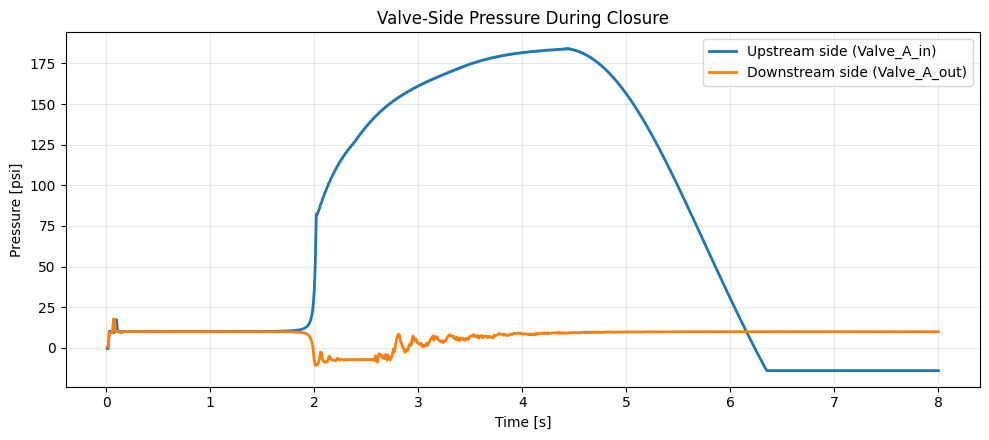

In [19]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(baseline_time, baseline_upstream_pressure, label="Upstream side (Valve_A_in)", linewidth=2.0)
ax.plot(baseline_time, baseline_downstream_pressure, label="Downstream side (Valve_A_out)", linewidth=2.0)
ax.set_title("Valve-Side Pressure During Closure")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Pressure [psi]")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 4b. Plot Upstream Pipe Flow Through the Closure

This view tracks the transient response in `Pipe_1` so the change in momentum is visible alongside the pressure rise.

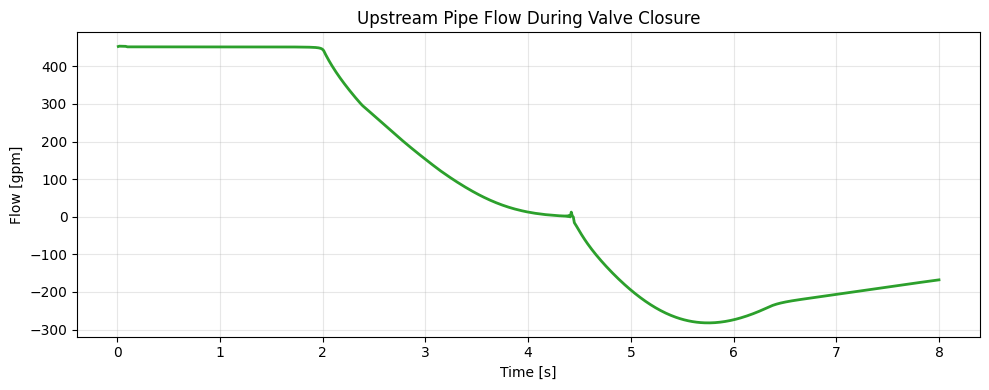

In [20]:
fig, ax = plt.subplots(figsize=(10, 4.0))
ax.plot(baseline_time, baseline_flow, color="tab:green", linewidth=2.0)
ax.set_title("Upstream Pipe Flow During Valve Closure")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Flow [gpm]")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4c. Initial and Global Peak-Head Checks

This chart separates the initial post-closure surge from the later global maximum. The dashed orange line checks the first peak against the approximate Joukowsky estimate, while the dotted green line checks the later global maximum against the checked-in R-THYM reference peak.

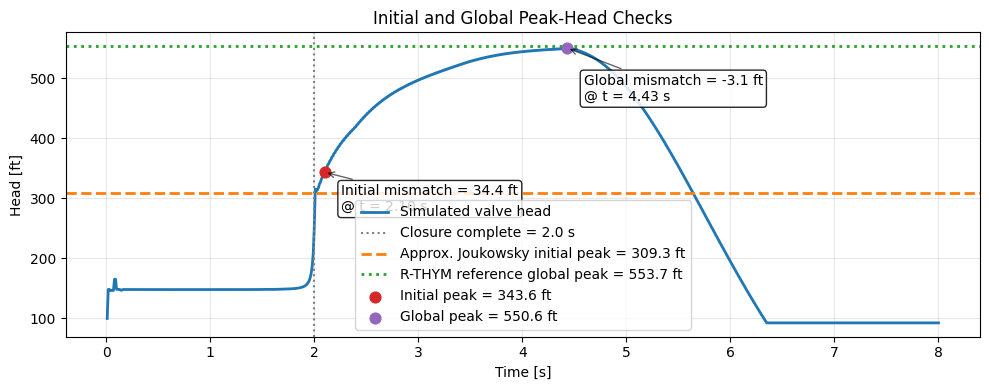

In [21]:
fig, ax = plt.subplots(figsize=(10, 4.0))
ax.plot(baseline_time, baseline_head, color="tab:blue", linewidth=2.0, label="Simulated valve head")
ax.axvline(closure_time, color="0.5", linestyle=":", linewidth=1.5, label=f"Closure complete = {closure_time:.1f} s")
ax.axhline(expected_peak_head, color="tab:orange", linestyle="--", linewidth=2.0, label=f"Approx. Joukowsky initial peak = {expected_peak_head:.1f} ft")
ax.axhline(reference_global_peak_head, color="tab:green", linestyle=":", linewidth=2.0, label=f"R-THYM reference global peak = {reference_global_peak_head:.1f} ft")
ax.scatter([initial_peak_time], [initial_peak_head], color="tab:red", s=60, zorder=3, label=f"Initial peak = {initial_peak_head:.1f} ft")
ax.scatter([global_peak_time], [global_peak_head], color="tab:purple", s=60, zorder=3, label=f"Global peak = {global_peak_head:.1f} ft")
ax.annotate(
    f"Initial mismatch = {joukowsky_head_gap:.1f} ft\n@ t = {initial_peak_time:.2f} s",
    xy=(initial_peak_time, initial_peak_head),
    xytext=(12, -28),
    textcoords="offset points",
    bbox={"boxstyle": "round,pad=0.25", "fc": "white", "alpha": 0.85},
    arrowprops={"arrowstyle": "->", "alpha": 0.6},
)
ax.annotate(
    f"Global mismatch = {global_peak_reference_gap:.1f} ft\n@ t = {global_peak_time:.2f} s",
    xy=(global_peak_time, global_peak_head),
    xytext=(12, -38),
    textcoords="offset points",
    bbox={"boxstyle": "round,pad=0.25", "fc": "white", "alpha": 0.85},
    arrowprops={"arrowstyle": "->", "alpha": 0.6},
)
ax.set_title("Initial and Global Peak-Head Checks")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Head [ft]")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 4d. Plot the Valve Closure Schedule

The forcing function is shown explicitly here so the pressure and flow plots can be read against the commanded valve motion.

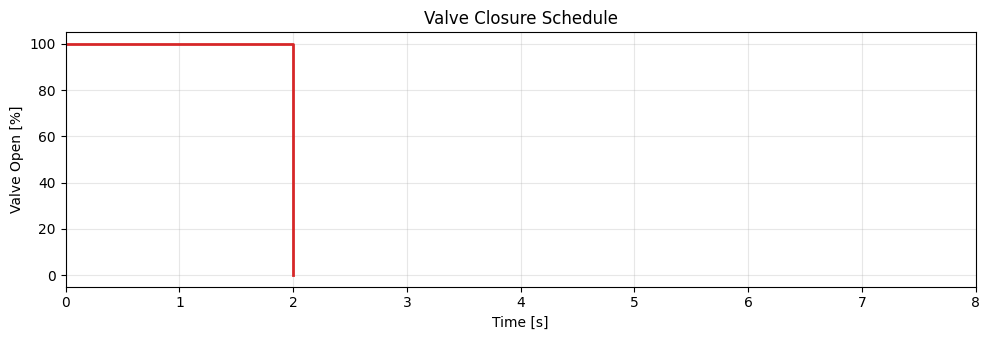

In [29]:
schedule_array = np.asarray(exploratory_valve_schedule, dtype=float)
schedule_time = schedule_array[:, 0]
schedule_pct_open = schedule_array[:, 1]
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.step(schedule_time, schedule_pct_open, where="post", color="tab:red", linewidth=2.0)
ax.set_title("Valve Closure Schedule")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Valve Open [%]")
ax.set_xlim(0.0, SIM_TOTAL_TIME)
ax.set_ylim(-5, 105)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Repeat the Same Exploratory Simulation to Verify Determinism

A fresh solver instance is built from the same committed inputs, then run again with identical settings. Rebuilding the solver avoids any ambiguity around in-memory state from the first run.

In [23]:
repeat_solver = make_solver(exploratory_valve_schedule)
repeat_results = repeat_solver.run(total_time=SIM_TOTAL_TIME, dt=SIM_DT)

repeat_time = np.asarray(repeat_results["time"])
repeat_head = np.asarray(repeat_results["node_head"]["_VALVE_Valve_A"])
repeat_pressure = np.asarray(repeat_results["node_pressure"]["_VALVE_Valve_A"])
repeat_flow = np.asarray(repeat_results["pipe_flow_gpm"]["Pipe_1"])

print(f"Repeated run peak head: {repeat_head.max():.3f} ft")
print(f"Repeated run peak pressure: {repeat_pressure.max():.3f} psi")

Repeated run peak head: 550.593 ft
Repeated run peak pressure: 184.239 psi


## 6. Compare Time-Series Outputs Numerically

The next cell compares the repeated runs using exact equality and explicit max-difference checks. For this fixed-input case, the expected tolerance is zero because no random inputs are involved.

In [24]:
determinism_metrics = {
    "max_abs_diff_time": float(np.max(np.abs(baseline_time - repeat_time))),
    "max_abs_diff_head_ft": float(np.max(np.abs(baseline_head - repeat_head))),
    "max_abs_diff_pressure_psi": float(np.max(np.abs(baseline_pressure - repeat_pressure))),
    "max_abs_diff_flow_gpm": float(np.max(np.abs(baseline_flow - repeat_flow))),
}

print(json.dumps(determinism_metrics, indent=2))
assert np.array_equal(baseline_time, repeat_time)
assert np.array_equal(baseline_head, repeat_head)
assert np.array_equal(baseline_pressure, repeat_pressure)
assert np.array_equal(baseline_flow, repeat_flow)
print("Repeated deterministic runs matched exactly.")

{
  "max_abs_diff_time": 0.0,
  "max_abs_diff_head_ft": 0.0,
  "max_abs_diff_pressure_psi": 0.0,
  "max_abs_diff_flow_gpm": 0.0
}
Repeated deterministic runs matched exactly.


## 7. Optional: Seed NumPy for Synthetic Input Generation

The production solver and current tests do not rely on random inputs, but seeded synthetic data is still useful for benchmark matrices, perturbation studies, or fuzz-like scenario generation. The next cells keep the randomness explicit and reproducible with `numpy.random.default_rng`.

## 8. Generate Seeded Synthetic Demand Variations

This Joukowsky benchmark has no demand nodes, so the synthetic perturbation is applied to the downstream fixed-head boundary instead. The helper returns a reproducible head schedule for `PressureBoundary_B` from a chosen seed.

In [25]:
SEEDED_TOLERANCE = 0.0
SCHEDULE_TIMES = np.array([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0])
BASE_DOWNSTREAM_HEAD = BASE_INITIAL_HEADS["PressureBoundary_B"]


def make_seeded_head_schedule(seed: int, amplitude_ft: float = 0.35):
    rng = np.random.default_rng(seed)
    offsets = rng.normal(loc=0.0, scale=amplitude_ft, size=len(SCHEDULE_TIMES) - 1)
    schedule_values = np.concatenate(([BASE_DOWNSTREAM_HEAD], BASE_DOWNSTREAM_HEAD + offsets))
    schedule = list(zip(SCHEDULE_TIMES.tolist(), schedule_values.tolist()))
    return schedule, schedule_values


schedule_a, values_a = make_seeded_head_schedule(2026)
schedule_b, values_b = make_seeded_head_schedule(2026)
schedule_c, values_c = make_seeded_head_schedule(7)

print("Seed 2026 schedule preview:", schedule_a[:3])
assert np.array_equal(values_a, values_b)
assert not np.array_equal(values_a, values_c)
print("The same seed reproduced identical synthetic inputs; a different seed changed them.")

Seed 2026 schedule preview: [(0.0, 147.9), (1.0, 147.62240713369474), (2.0, 147.9841999492384)]
The same seed reproduced identical synthetic inputs; a different seed changed them.


## 9. Re-run Simulations with Seeded Inputs

The same seeded schedule should reproduce identical outputs, while a different seed should change the generated boundary schedule and therefore the resulting traces.

In [28]:
def run_seeded_case(seed: int):
    solver = make_solver(exploratory_valve_schedule)
    schedule, schedule_values = make_seeded_head_schedule(seed)
    solver.set_head_schedule("PressureBoundary_B", schedule)
    results = solver.run(total_time=SIM_TOTAL_TIME, dt=SIM_DT)
    return schedule_values, results


seeded_values_1, seeded_results_1 = run_seeded_case(2026)
seeded_values_2, seeded_results_2 = run_seeded_case(2026)
seeded_values_3, seeded_results_3 = run_seeded_case(7)

seeded_head_1 = np.asarray(seeded_results_1["node_head"]["_VALVE_Valve_A"])
seeded_head_2 = np.asarray(seeded_results_2["node_head"]["_VALVE_Valve_A"])
seeded_head_3 = np.asarray(seeded_results_3["node_head"]["_VALVE_Valve_A"])

same_seed_max_diff = float(np.max(np.abs(seeded_head_1 - seeded_head_2)))
different_seed_max_diff = float(np.max(np.abs(seeded_head_1 - seeded_head_3)))

print(f"Same-seed max head difference: {same_seed_max_diff:.6f} ft")
print(f"Different-seed max head difference: {different_seed_max_diff:.6f} ft")
assert np.array_equal(seeded_values_1, seeded_values_2)
assert np.array_equal(seeded_head_1, seeded_head_2)
assert same_seed_max_diff <= SEEDED_TOLERANCE
assert different_seed_max_diff > 0.0
print("Seeded synthetic runs are reproducible when the seed is fixed.")

Same-seed max head difference: 0.000000 ft
Different-seed max head difference: 0.269412 ft
Seeded synthetic runs are reproducible when the seed is fixed.


## 10. Persist Reproducible Results for Regression Checks

The final cell writes selected outputs and metadata to disk so the notebook can double as a repeatable validation workflow and a starting point for future regression assets.

In [ ]:
metadata = {
    "package_version": getattr(rthym_moc, "__version__", "unknown"),
    "asset_inp": str(ASSET_INP.relative_to(REPO_ROOT)),
    "asset_json": str(ASSET_JSON.relative_to(REPO_ROOT)),
    "simulation_total_time_s": SIM_TOTAL_TIME,
    "simulation_dt_s": SIM_DT,
    "determinism_metrics": determinism_metrics,
    "seeded_tolerance_ft": SEEDED_TOLERANCE,
    "seeded_example_seed": 2026,
}

metadata_path = OUTPUT_DIR / "quickstart_notebook_metadata.json"
trace_path = OUTPUT_DIR / "quickstart_notebook_baseline_trace.csv"

metadata_path.write_text(json.dumps(metadata, indent=2))

trace_matrix = np.column_stack((baseline_time, baseline_head, baseline_pressure, baseline_flow))
np.savetxt(
    trace_path,
    trace_matrix,
    delimiter=",",
    header="time_s,valve_head_ft,valve_pressure_psi,pipe_1_flow_gpm",
    comments="",
)

print(f"Wrote metadata to {metadata_path}")
print(f"Wrote baseline trace to {trace_path}")

Wrote metadata to /home/jason/RTHYM-MOC/examples/notebook_outputs/quickstart_notebook_metadata.json
Wrote baseline trace to /home/jason/RTHYM-MOC/examples/notebook_outputs/quickstart_notebook_baseline_trace.csv


## 10a. Reload and Visualize the Saved Artifacts

The next cell reads the CSV and JSON that were just written and plots the persisted baseline traces. This makes it clear that the exported files are immediately reusable for regression review, reporting, or downstream tooling.

In [ ]:
saved_metadata = json.loads(metadata_path.read_text())
saved_trace = np.loadtxt(trace_path, delimiter=",", skiprows=1)
saved_time = saved_trace[:, 0]
saved_head = saved_trace[:, 1]
saved_pressure = saved_trace[:, 2]
saved_flow = saved_trace[:, 3]
fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True, height_ratios=(2, 1.6))
ax_top.plot(saved_time, saved_head, color="tab:blue", linewidth=2.0, label="Persisted valve head")
ax_top.plot(saved_time, saved_pressure, color="tab:orange", linewidth=2.0, label="Persisted valve pressure")
ax_top.set_title("Reloaded Baseline Traces from Saved CSV")
ax_top.set_ylabel("Head [ft] / Pressure [psi]")
ax_top.grid(True, alpha=0.3)
ax_top.legend(loc="upper right")
ax_bottom.plot(saved_time, saved_flow, color="tab:green", linewidth=2.0, label="Persisted Pipe_1 flow")
ax_bottom.set_xlabel("Time [s]")
ax_bottom.set_ylabel("Flow [gpm]")
ax_bottom.grid(True, alpha=0.3)
ax_bottom.legend(loc="upper right")
fig.suptitle(f"Saved run package version: {saved_metadata['package_version']}", y=0.98)
plt.tight_layout()
plt.show()